# 04 · Aplicação prática

**Teste prático de Analytics Engineer (estágio) · Klubi**

Tarefa 4 do desafio: "até aqui a base foi descrita, agora queremos ver o que dá para **fazer** com ela".

### A aplicação

**Triagem de risco acadêmico com simulador de intervenção**, entregue como app Streamlit.

| | |
|---|---|
| **Que decisão apoia** | Quem chamar para reforço antes da prova, e o que recomendar para cada aluno chamado |
| **Quem usaria** | Coordenação pedagógica e tutoria |
| **Entrada** | Os hábitos de um aluno, escolhido na base ou cadastrado na hora |
| **Saída** | Nota prevista com faixa de incerteza, veredito de risco, e a lista de mudanças de hábito ordenada por quantos pontos cada uma renderia |

A escolha vem do que os notebooks anteriores encontraram. O notebook 03 mostrou que seis hábitos explicam 90% da variação da nota, o que torna a previsão viável, e que entre alunos que estudam o mesmo tanto são saúde mental e tempo de tela que separam o resultado. Isso é exatamente o que um tutor precisa saber para recomendar algo que caiba na vida do aluno.

### Índice

1. Setup
2. Base preparada
3. Escolha do modelo
4. O modelo escolhido
5. O teto reaparece sozinho
6. Triagem: quem está em risco
7. A zona de incerteza
8. Simulador: o que mudar primeiro
9. O app
10. Síntese

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (confusion_matrix, mean_absolute_error,
                             root_mean_squared_error)
from sklearn.model_selection import KFold, cross_val_score, train_test_split

CSV = Path("../data/raw/habitos_e_desempenho_estudantil.csv")
if not CSV.exists():
    CSV = Path("data/raw/habitos_e_desempenho_estudantil.csv")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

SEMENTE = 42   # fixa para o notebook ser reproduzível
print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")

pandas 3.0.6  ·  numpy 2.5.3


In [2]:
# Mesma paleta dos notebooks anteriores, mais as cores de status usadas pelo
# veredito. Status nunca aparece sozinho: sempre acompanhado de rótulo em texto.
COR = {
    "serie_1":    "#2a78d6",
    "serie_2":    "#eb6834",
    "superficie": "#fcfcfb",
    "tinta":      "#0b0b0b",
    "tinta_2":    "#52514e",
    "suave":      "#898781",
    "grade":      "#e1e0d9",
    "eixo":       "#c3c2b7",
    "bom":        "#0ca30c",
    "atencao":    "#fab219",
    "critico":    "#d03b3b",
}

plt.rcParams.update({
    "figure.facecolor":   COR["superficie"],
    "axes.facecolor":     COR["superficie"],
    "savefig.facecolor":  COR["superficie"],
    "figure.dpi":         110,
    "font.family":        "sans-serif",
    "font.size":          9.5,
    "text.color":         COR["tinta"],
    "axes.titlesize":     10.5,
    "axes.titleweight":   "bold",
    "axes.titlecolor":    COR["tinta"],
    "axes.titlelocation": "left",
    "axes.titlepad":      9,
    "axes.labelsize":     9,
    "axes.labelcolor":    COR["tinta_2"],
    "axes.edgecolor":     COR["eixo"],
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         COR["grade"],
    "grid.linewidth":     0.8,
    "grid.linestyle":     "-",
    "xtick.color":        COR["suave"],
    "ytick.color":        COR["suave"],
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "xtick.bottom":       False,
    "ytick.left":         False,
    "legend.frameon":     False,
    "legend.fontsize":    9,
})


def so_grade(ax, eixo="y"):
    "Deixa grade em um eixo só. O dado é a única coisa que pode ser forte."
    ax.grid(axis=eixo, visible=True)
    ax.grid(axis="x" if eixo == "y" else "y", visible=False)
    return ax

## 2. Base preparada

`preparar_dados()` do [notebook 02](02_engenharia_de_dados.ipynb), sem alteração.

In [3]:
INTEIRAS = ["age", "exercise_frequency", "mental_health_rating"]
DECIMAIS = ["study_hours_per_day", "social_media_hours", "netflix_hours",
            "attendance_percentage", "sleep_hours", "exam_score"]
ORDINAIS = {
    "diet_quality":             ["Poor", "Fair", "Good"],
    "internet_quality":         ["Poor", "Average", "Good"],
    "parental_education_level": ["None", "High School", "Bachelor", "Master"],
}
FAIXAS = {
    "faixa_estudo": ("study_hours_per_day", [0, 2, 3, 4, 5, np.inf],
                     ["menos de 2h", "2h a 3h", "3h a 4h", "4h a 5h", "5h ou mais"]),
    "faixa_redes":  ("social_media_hours", [0, 1, 2, 3, 4, np.inf],
                     ["menos de 1h", "1h a 2h", "2h a 3h", "3h a 4h", "4h ou mais"]),
    "faixa_sono":   ("sleep_hours", [0, 6, 7, 8, np.inf],
                     ["menos de 6h", "6h a 7h", "7h a 8h", "8h ou mais"]),
}


def preparar_dados(csv=CSV):
    "Lê o CSV cru e devolve a base tratada. Idêntica à do notebook 02."
    base = pd.read_csv(csv, dtype=str, na_filter=False)
    base[INTEIRAS] = base[INTEIRAS].astype(int)
    base[DECIMAIS] = base[DECIMAIS].astype(float)

    for coluna, ordem in ORDINAIS.items():
        base[coluna] = pd.Categorical(base[coluna], categories=ordem, ordered=True)
        base[f"{coluna}_cod"] = base[coluna].cat.codes

    base["tempo_tela_total"] = base["social_media_hours"] + base["netflix_hours"]

    for nova, (origem, cortes, rotulos) in FAIXAS.items():
        base[nova] = pd.cut(base[origem], bins=cortes, labels=rotulos,
                            right=False, ordered=True)
    return base


df = preparar_dados()

# Os seis preditores com efeito detectável, segundo o notebook 03. As outras seis
# variáveis da base tinham intervalo de confiança contendo o zero e ficam de fora.
MODELO = ["study_hours_per_day", "mental_health_rating", "tempo_tela_total",
          "exercise_frequency", "sleep_hours", "attendance_percentage"]
ALVO = "exam_score"

X, y = df[MODELO], df[ALVO]
print(f"{len(df)} alunos · {len(MODELO)} preditores")

1000 alunos · 6 preditores


## 3. Escolha do modelo

Regressão linear parece a escolha óbvia depois do notebook 03: as relações são lineares e os preditores são independentes. Mas "óbvio" não é argumento, e escolher o modelo mais simples sem testar os outros é preguiça disfarçada de parcimônia.

Se existir estrutura que uma reta não enxerga (curva, interação entre hábitos, efeito de limiar), um modelo mais flexível deveria encontrá-la e vencer. Então comparo **oito famílias**, cada uma com busca em grade sobre os hiperparâmetros que importam, todas avaliadas nos mesmos cinco folds.

In [4]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

kf = KFold(n_splits=5, shuffle=True, random_state=SEMENTE)

# Modelos sensíveis a escala (Ridge, Lasso, ElasticNet, SVR, KNN) entram num
# pipeline com StandardScaler. Padronizar dentro do pipeline garante que a média
# e o desvio sejam calculados só no fold de treino, sem vazar o de validação.
BUSCAS = {
    "Regressão linear": (LinearRegression(), {}),
    "Ridge": (make_pipeline(StandardScaler(), Ridge()),
              {"ridge__alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (make_pipeline(StandardScaler(), Lasso(max_iter=5000)),
              {"lasso__alpha": [0.001, 0.01, 0.1, 1]}),
    "ElasticNet": (make_pipeline(StandardScaler(), ElasticNet(max_iter=5000)),
                   {"elasticnet__alpha": [0.01, 0.1, 1],
                    "elasticnet__l1_ratio": [0.2, 0.5, 0.8]}),
    "KNN": (make_pipeline(StandardScaler(), KNeighborsRegressor()),
            {"kneighborsregressor__n_neighbors": [5, 10, 20, 40],
             "kneighborsregressor__weights": ["uniform", "distance"]}),
    "SVR": (make_pipeline(StandardScaler(), SVR()),
            {"svr__C": [1, 10, 100], "svr__gamma": ["scale", 0.05]}),
    "Random Forest": (RandomForestRegressor(random_state=SEMENTE, n_jobs=-1),
                      {"n_estimators": [200, 500], "max_depth": [None, 8, 16],
                       "min_samples_leaf": [1, 4]}),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=SEMENTE),
                          {"n_estimators": [200, 500], "learning_rate": [0.03, 0.1],
                           "max_depth": [2, 3]}),
}

linhas = []
for nome, (estimador, grade) in BUSCAS.items():
    if grade:
        busca = GridSearchCV(estimador, grade, cv=kf, scoring="r2", n_jobs=-1).fit(X, y)
        melhor, r2, params = busca.best_estimator_, busca.best_score_, busca.best_params_
        n_config = len(busca.cv_results_["params"])
    else:
        melhor, params, n_config = estimador, {}, 1
        r2 = cross_val_score(estimador, X, y, cv=kf, scoring="r2").mean()

    mae = -cross_val_score(melhor, X, y, cv=kf,
                           scoring="neg_mean_absolute_error").mean()
    linhas.append({
        "modelo": nome, "r2": r2, "mae": mae, "configs": n_config,
        # tira o prefixo do pipeline ("ridge__alpha" vira "alpha") para a tabela ler melhor
        "melhores_hiperparametros": {k.split("__")[-1]: v for k, v in params.items()},
    })

comparacao = pd.DataFrame(linhas).set_index("modelo").sort_values("r2", ascending=False)
print(f"{comparacao['configs'].sum()} configurações testadas em "
      f"{len(BUSCAS)} famílias de modelo\n")
comparacao

53 configurações testadas em 8 famílias de modelo



,r2,mae,configs,melhores_hiperparametros
modelo,,,,
Ridge,0.897,4.252,5,{'alpha': 0.1}
Regressão linear,0.897,4.252,1,{}
Lasso,0.897,4.253,4,{'alpha': 0.001}
ElasticNet,0.897,4.253,9,"{'alpha': 0.01, 'l1_ratio': 0.8}"
SVR,0.895,4.277,6,"{'C': 10, 'gamma': 0.05}"
Gradient Boosting,0.891,4.423,8,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
Random Forest,0.868,4.855,12,"{'max_depth': 16, 'min_samples_leaf': 1, 'n_es..."
KNN,0.819,5.639,8,"{'n_neighbors': 10, 'weights': 'distance'}"


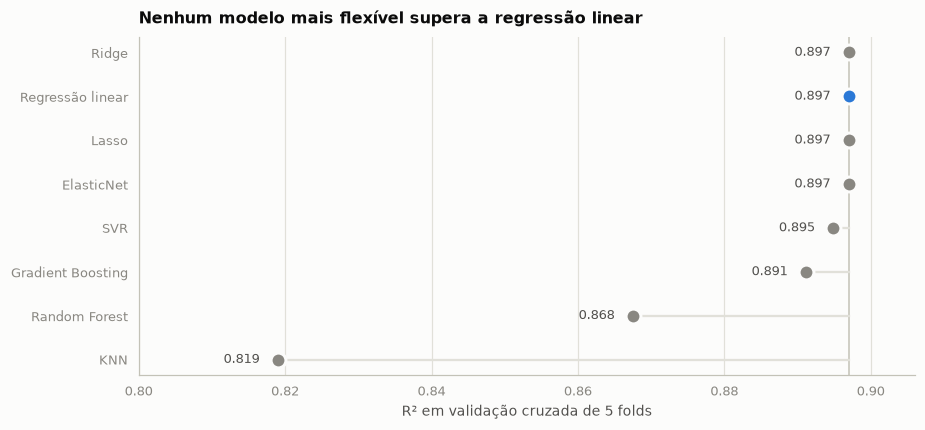

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4))

c = comparacao.iloc[::-1]
# Pontos, e não barras: o eixo não começa em zero, e barra truncada mente sobre
# a proporção entre os valores. Ponto marca posição sem sugerir comprimento.
cores = [COR["serie_1"] if nome == "Regressão linear" else COR["suave"]
         for nome in c.index]

melhor_r2 = comparacao["r2"].max()
ax.axvline(melhor_r2, color=COR["eixo"], linewidth=1, zorder=1)

for i, (nome, linha) in enumerate(c.iterrows()):
    ax.plot([linha["r2"], melhor_r2], [i, i], color=COR["grade"], linewidth=1.5, zorder=2)
    ax.scatter(linha["r2"], i, s=95, color=cores[i],
               edgecolor=COR["superficie"], linewidth=2, zorder=3)
    ax.text(linha["r2"] - 0.0025, i, f"{linha['r2']:.3f}", va="center", ha="right",
            fontsize=8.5, color=COR["tinta_2"])

ax.set_yticks(np.arange(len(c)), c.index)
ax.set_xlabel("R² em validação cruzada de 5 folds")
ax.set_title("Nenhum modelo mais flexível supera a regressão linear")
ax.set_xlim(0.80, 0.906)
so_grade(ax, eixo="x")
plt.tight_layout()
plt.show()

**53 configurações, oito famílias, e nada bate a reta.**

| Modelo | R² | MAE | Melhor configuração |
|---|---|---|---|
| Ridge | 0,89700 | 4,252 | `alpha=0,1` |
| **Regressão linear** | **0,89700** | **4,252** | sem hiperparâmetro |
| Lasso | 0,89700 | 4,253 | `alpha=0,001` |
| ElasticNet | 0,89699 | 4,253 | `alpha=0,01`, `l1_ratio=0,8` |
| SVR | 0,89487 | 4,277 | `C=10`, `gamma=0,05` |
| Gradient Boosting | 0,89114 | 4,423 | 200 árvores, profundidade 2 |
| Random Forest | 0,86752 | 4,855 | 200 árvores, profundidade 16 |
| KNN | 0,81902 | 5,639 | 10 vizinhos, peso por distância |

O resultado tem duas leituras, e as duas confirmam o notebook 03.

**Os lineares regularizados empatam com a regressão simples.** Ridge, Lasso e ElasticNet convergem para praticamente o mesmo R², e escolhem o menor alpha da grade em todos os casos. Regularização serve para domar colinearidade e superajuste, e aqui não há nem um nem outro: com seis preditores independentes e mil observações, não sobra o que encolher. O Ridge aparece em primeiro por uma diferença na nona casa decimal, que é ruído, não vitória.

**Os não lineares perdem, e perdem na ordem esperada.** Gradient Boosting fica 0,006 abaixo, Random Forest 0,03, KNN 0,08. Árvore não vence reta quando a relação **é** uma reta: ela aproxima a inclinação por degraus e paga em variância o que não ganha em viés. O KNN sofre ainda mais porque, num espaço de seis dimensões com variáveis independentes, vizinhança deixa de significar semelhança.

A escolha fica com a **regressão linear**, e por dois motivos independentes: ela empata no topo da métrica, e é a única cujos coeficientes o simulador da seção 8 consegue ler direto como "pontos de nota por unidade de hábito".

## 4. O modelo escolhido

Ajustando a regressão linear num conjunto de teste separado, para ter uma medida fora da validação cruzada que escolheu o modelo.

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEMENTE)

modelo = LinearRegression().fit(X_tr, y_tr)
previsto_te = modelo.predict(X_te)

# O desvio-padrão do resíduo é o número mais importante deste notebook: é o
# tamanho típico do erro, e portanto define a largura da zona de incerteza
# usada no veredito da seção 7.
desvio_residuo = float(np.std(y_te - previsto_te))

print(f"R²   em teste : {modelo.score(X_te, y_te):.3f}")
print(f"MAE  em teste : {mean_absolute_error(y_te, previsto_te):.2f} pontos")
print(f"RMSE em teste : {root_mean_squared_error(y_te, previsto_te):.2f} pontos")
print(f"desvio do resíduo: {desvio_residuo:.2f} pontos")

R²   em teste : 0.900
MAE  em teste : 4.12 pontos
RMSE em teste : 5.07 pontos
desvio do resíduo: 5.07 pontos


In [7]:
# Uma divisão só pode ter dado sorte. Os mesmos cinco folds da seção 3 mostram
# a variação real.
r2_cv = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")
mae_cv = -cross_val_score(LinearRegression(), X, y, cv=kf,
                          scoring="neg_mean_absolute_error")

print(f"R²  em 5 folds: {r2_cv.mean():.3f} ± {r2_cv.std():.3f}")
print(f"MAE em 5 folds: {mae_cv.mean():.2f} ± {mae_cv.std():.2f} pontos")

R²  em 5 folds: 0.897 ± 0.019
MAE em 5 folds: 4.25 ± 0.25 pontos


In [8]:
coeficientes = pd.Series(modelo.coef_, index=MODELO, name="pontos_por_unidade")
coeficientes.to_frame().assign(
    unidade=["1 hora/dia", "1 ponto na escala", "1 hora/dia",
             "1 dia/semana", "1 hora/noite", "1 ponto percentual"]
)

,pontos_por_unidade,unidade
study_hours_per_day,9.536,1 hora/dia
mental_health_rating,1.946,1 ponto na escala
tempo_tela_total,-2.523,1 hora/dia
exercise_frequency,1.318,1 dia/semana
sleep_hours,1.989,1 hora/noite
attendance_percentage,0.146,1 ponto percentual


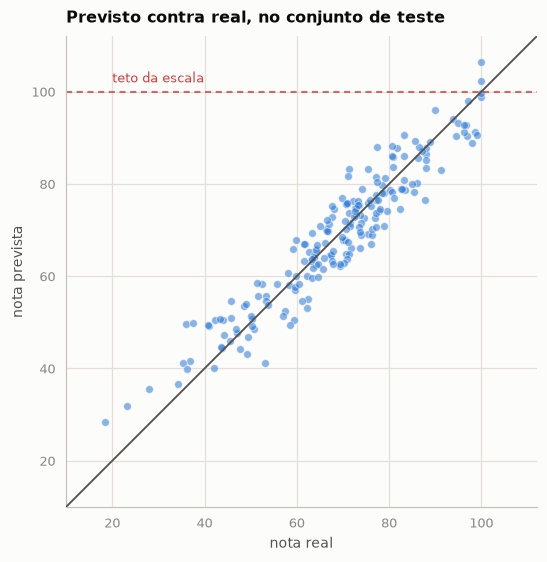

In [9]:
fig, ax = plt.subplots(figsize=(5.6, 5.2))

ax.scatter(y_te, previsto_te, s=26, color=COR["serie_1"], alpha=0.55,
           edgecolor=COR["superficie"], linewidth=0.6)

# Reta de acerto perfeito: quanto mais perto dela, melhor a previsão.
limites = [0, 115]
ax.plot(limites, limites, color=COR["tinta_2"], linewidth=1.2, zorder=3)
ax.axhline(100, color=COR["critico"], linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.text(20, 102, "teto da escala", color=COR["critico"], fontsize=8.5)

ax.set_xlabel("nota real")
ax.set_ylabel("nota prevista")
ax.set_title("Previsto contra real, no conjunto de teste")
ax.set_xlim(10, 112)
ax.set_ylim(10, 112)
ax.set_aspect("equal")
so_grade(ax, eixo="both")
ax.grid(visible=True)
plt.tight_layout()
plt.show()

**R² de 0,900 em teste e 0,897 ± 0,019 em cinco folds.** O erro médio é de **4,1 pontos** numa escala de 0 a 100, e o desvio do resíduo é de 5,07.

Os coeficientes são os mesmos do notebook 03, agora vindos do sklearn: cada hora de estudo por dia vale **+9,5 pontos**, cada ponto de saúde mental **+1,9**, cada hora de tela **-2,5**.

No gráfico os pontos acompanham a reta de acerto perfeito de ponta a ponta, sem curva nem funil, o que confirma que linear era a forma certa. Só há uma anomalia, e ela está acima da linha tracejada.

## 5. O teto reaparece sozinho

Alguns pontos do gráfico estão **acima de 100**, que é o máximo que a prova pode valer. O modelo não sabe disso: ele nunca foi informado de que existe um teto, apenas aprendeu a relação entre hábitos e nota.

Vale investigar quem são esses alunos.

In [10]:
# Previsão fora-de-fold para a base inteira: cada aluno é previsto por um modelo
# que não o viu no treino. Sem isso as previsões seriam otimistas.
previsto_oof = np.empty(len(y))
for treino, teste in kf.split(X):
    ajuste = LinearRegression().fit(X.iloc[treino], y.iloc[treino])
    previsto_oof[teste] = ajuste.predict(X.iloc[teste])

acima_do_teto = previsto_oof > 100
no_teto = (y == 100).to_numpy()

print(f"alunos com previsão acima de 100 : {acima_do_teto.sum()}")
print(f"  destes, com nota real igual a 100 : {(y[acima_do_teto] == 100).sum()}")
print(f"  nota real média destes            : {y[acima_do_teto].mean():.1f}")
print()
print(f"alunos com nota exatamente 100   : {no_teto.sum()}")
print(f"  previsão média deles              : {previsto_oof[no_teto].mean():.1f}")
print(f"  maior previsão da base            : {previsto_oof.max():.1f}")

alunos com previsão acima de 100 : 37
  destes, com nota real igual a 100 : 32
  nota real média destes            : 99.5

alunos com nota exatamente 100   : 48
  previsão média deles              : 103.1
  maior previsão da base            : 123.1


**Dos 48 alunos que tiraram exatamente 100, a previsão média é 103,1.** E dos 37 alunos que o modelo coloca acima de 100, 32 tiraram exatamente 100, com média real de 99,5.

Isso é o comportamento esperado de um modelo linear perto de um teto, e vale ser precisa sobre o que ele prova e o que não prova. O modelo não sabe que existe um limite em 100 e continua a reta depois dele, então prevê valores acima de 100 justamente para quem já está no teto. **Isso aconteceria de qualquer forma**, seja o teto uma saturação genuína da prova ou censura de uma nota mais alta (notebook 01, seção 6): as duas hipóteses produzem exatamente esse mesmo padrão, e o modelo não tem como distinguir entre elas. O que fica confirmado é que o teto distorce a estimativa perto dele, não qual das duas hipóteses é a certa.

Para o app a decisão é simples: **truncar em 100 na exibição, guardando o valor bruto**. Mostrar "nota prevista: 103" confundiria o usuário, mas o valor cru é informativo, porque distingue quem está no teto com folga de quem chegou nele raspando.

## 6. Triagem: quem está em risco

Primeira metade da aplicação. Com a previsão de cada aluno, a coordenação consegue ordenar a turma por risco **antes** da prova, em vez de descobrir quem reprovou depois dela.

O corte de 60 é o mesmo usado como referência no notebook 01, e reprova 28% da base. Ele é uma régua institucional, não sai do dado, e no app fica ajustável.

In [11]:
CORTE = 60

triagem = pd.DataFrame({
    "student_id": df["student_id"],
    "prevista": previsto_oof,
    "real": y,
    "estudo_h": df["study_hours_per_day"],
    "saude_mental": df["mental_health_rating"],
    "tela_h": df["tempo_tela_total"],
}).sort_values("prevista")

print("os 6 alunos de maior risco previsto:")
triagem.head(6)

os 6 alunos de maior risco previsto:


,student_id,prevista,real,estudo_h,saude_mental,tela_h
434,S1434,20.804,26.200,0.000,2,6.700
431,S1431,23.932,29.900,0.000,2,4.500
129,S1129,26.381,26.800,0.300,3,5.700
790,S1790,28.217,31.500,0.800,5,6.300
265,S1265,28.369,18.400,0.600,4,6.100
195,S1195,30.070,26.700,0.000,5,4.400


In [12]:
real_reprova = (y < CORTE).to_numpy()
prev_reprova = previsto_oof < CORTE

vn, fp, fn, vp = confusion_matrix(real_reprova, prev_reprova).ravel()
acuracia = (real_reprova == prev_reprova).mean()

print(f"acurácia : {acuracia:.3f}   (baseline chutando 'todos passam': {1 - real_reprova.mean():.3f})")
print(f"recall   : {vp / (vp + fn):.3f}   dos que reprovam, quantos o modelo pega")
print(f"precisão : {vp / (vp + fp):.3f}   dos que ele aponta, quantos reprovam mesmo")
print()
pd.DataFrame(
    [[vn, fp], [fn, vp]],
    index=["passou de verdade", "reprovou de verdade"],
    columns=["modelo diz: passa", "modelo diz: reprova"],
)

acurácia : 0.921   (baseline chutando 'todos passam': 0.720)
recall   : 0.850   dos que reprovam, quantos o modelo pega
precisão : 0.865   dos que ele aponta, quantos reprovam mesmo



,modelo diz: passa,modelo diz: reprova
passou de verdade,683,37
reprovou de verdade,42,238


**Acurácia de 0,921, contra 0,720 de simplesmente chutar que todo mundo passa.** O modelo pega **85%** dos que vão reprovar, e dos que ele aponta, **86,5%** reprovam de fato.

Para o uso pretendido, os dois tipos de erro custam coisas diferentes:

1. **42 falsos negativos** são alunos que vão reprovar e o modelo deixou passar. É o erro caro: ninguém os chama, e eles reprovam.
2. **37 falsos positivos** são alunos chamados para reforço que passariam de qualquer jeito. Custa uma conversa a mais, e nada além disso.

Como o erro caro é o primeiro, uma coordenação pode legitimamente querer **subir o corte do app** acima da régua oficial, aceitando chamar mais gente para perder menos aluno. É por isso que o corte é um slider, e não uma constante.

## 7. A zona de incerteza

A acurácia de 0,921 é uma média, e média esconde onde o modelo erra. Com erro típico de 5,07 pontos, um aluno previsto em 58 tira 62 sem nenhuma surpresa, e o veredito vira ao contrário.

Então a pergunta certa não é "o modelo acerta?", é **"onde ele acerta?"**.

In [13]:
distancia = np.abs(previsto_oof - CORTE)
acertou = real_reprova == prev_reprova

# Faixas medidas em múltiplos do erro típico, e não em pontos redondos: é o
# erro do modelo que define o que é "perto do corte".
limites = [0, desvio_residuo, 2 * desvio_residuo, 3 * desvio_residuo, np.inf]
rotulos = [f"até {desvio_residuo:.1f}", f"{desvio_residuo:.1f} a {2 * desvio_residuo:.1f}",
           f"{2 * desvio_residuo:.1f} a {3 * desvio_residuo:.1f}", f"mais de {3 * desvio_residuo:.1f}"]

faixa = pd.cut(distancia, bins=limites, labels=rotulos, right=False)
por_faixa = pd.DataFrame({"faixa": faixa, "acertou": acertou}).groupby(
    "faixa", observed=True)["acertou"].agg(["size", "mean"])
por_faixa.columns = ["alunos", "acerto"]
por_faixa.index.name = "distância do corte (pontos)"
por_faixa

,alunos,acerto
distância do corte (pontos),,
até 5.1,203,0.675
5.1 a 10.1,196,0.939
10.1 a 15.2,199,0.995
mais de 15.2,402,1.000


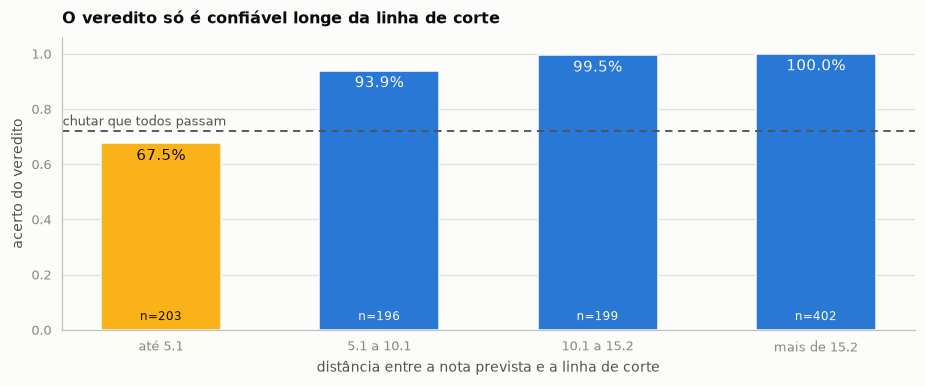

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))

# Só a primeira faixa recebe cor de alerta: é ela que justifica o terceiro
# estado do veredito. As demais ficam em azul porque ali o modelo é confiável.
cores = [COR["atencao"]] + [COR["serie_1"]] * (len(por_faixa) - 1)

ax.bar(np.arange(len(por_faixa)), por_faixa["acerto"], width=0.55, color=cores,
       edgecolor=COR["superficie"], linewidth=1)
baseline = 1 - real_reprova.mean()
ax.axhline(baseline, color=COR["tinta_2"], linewidth=1.2, linestyle=(0, (4, 3)))
# Anotação à esquerda, acima da linha: ali a primeira barra ainda não chegou.
ax.text(-0.45, baseline + 0.02, "chutar que todos passam",
        fontsize=8.5, color=COR["tinta_2"], ha="left")

for i, (v, n) in enumerate(zip(por_faixa["acerto"], por_faixa["alunos"])):
    # Rótulo dentro da barra: acima dela ele cruzaria a linha de referência.
    # A cor segue a luminância do preenchimento, para sempre ter contraste.
    cor_txt = COR["tinta"] if i == 0 else COR["superficie"]
    ax.text(i, v - 0.06, f"{v:.1%}", ha="center", fontsize=9.5, color=cor_txt)
    ax.text(i, 0.035, f"n={n}", ha="center", fontsize=8, color=cor_txt)

ax.set_xticks(np.arange(len(por_faixa)), por_faixa.index)
ax.set_xlabel("distância entre a nota prevista e a linha de corte")
ax.set_ylabel("acerto do veredito")
ax.set_title("O veredito só é confiável longe da linha de corte")
ax.set_ylim(0, 1.06)
so_grade(ax)
plt.tight_layout()
plt.show()

**Perto do corte o modelo é quase um chute: 67,5% de acerto**, contra 72,0% de simplesmente dizer que todo mundo passa. Nessa faixa ele é literalmente **pior que não ter modelo nenhum**. A partir de um erro típico de distância o acerto sobe para 93,9%, depois 99,5%, e além disso não erra.

São 203 alunos, 20% da turma, na faixa em que o número não deve ser levado a sério.

Daí a decisão de desenho mais importante do app: **o veredito tem três estados, não dois.**

| Estado | Quando | O que o app diz |
|---|---|---|
| Aprovação provável | previsão acima de corte + 5,1 | Sem sinal de risco |
| **Zona de incerteza** | previsão a menos de 5,1 do corte | Não dá para dizer, olhe o caso de perto |
| Risco de reprovação | previsão abaixo de corte - 5,1 | Candidato a reforço |

Cravar "vai reprovar" para quem está previsto em 58 com a mesma confiança de quem está em 35 seria vender uma precisão que o modelo não tem. E a zona de incerteza não é uma desculpa: ela é informação acionável, porque aponta exatamente os alunos em que vale gastar atenção humana em vez de confiar na conta.

## 8. Simulador: o que mudar primeiro

Segunda metade da aplicação. Saber que um aluno está em risco não diz o que fazer com ele. Como o modelo é linear e interpretável, cada coeficiente responde direto: **quantos pontos este aluno ganharia se mudasse este hábito?**

In [15]:
# Mudança realista de cada hábito, na direção que melhora a nota.
ALAVANCAS = {
    "study_hours_per_day":   (+1.0, "estudar 1h a mais por dia"),
    "mental_health_rating":  (+1.0, "subir 1 ponto na saúde mental"),
    "tempo_tela_total":      (-1.0, "cortar 1h de tela por lazer"),
    "sleep_hours":           (+1.0, "dormir 1h a mais por noite"),
    "exercise_frequency":    (+1.0, "exercitar-se 1 dia a mais"),
    "attendance_percentage": (+10.0, "subir 10 pontos de frequência"),
}

LIMITES = {c: (float(df[c].min()), float(df[c].max())) for c in MODELO}


def simular(habitos):
    "Ganho em pontos de cada mudança de hábito, respeitando os limites da base."
    atual = float(modelo.predict(pd.DataFrame([habitos]))[0])

    linhas = []
    for variavel, (delta, descricao) in ALAVANCAS.items():
        minimo, maximo = LIMITES[variavel]
        # np.clip impede sugerir o impossível, como 9h de estudo quando o máximo
        # observado é 8,3, ou tempo de tela negativo.
        novo = float(np.clip(habitos[variavel] + delta, minimo, maximo))
        if np.isclose(novo, habitos[variavel]):
            continue  # o aluno já está no limite: esta alavanca não existe para ele

        cenario = dict(habitos)
        cenario[variavel] = novo
        ganho = float(modelo.predict(pd.DataFrame([cenario]))[0]) - atual
        linhas.append({"acao": descricao, "ganho": ganho})

    return pd.DataFrame(linhas).sort_values("ganho", ascending=False).reset_index(drop=True)


# Aluno de maior risco da triagem, como exemplo.
exemplo_id = triagem.iloc[0]["student_id"]
exemplo = df.loc[df["student_id"] == exemplo_id].iloc[0]
habitos_exemplo = {c: float(exemplo[c]) for c in MODELO}

print(f"aluno {exemplo_id}: nota real {exemplo[ALVO]:.1f}, "
      f"prevista {triagem.iloc[0]['prevista']:.1f}")
print({k: round(v, 1) for k, v in habitos_exemplo.items()})
print()
simular(habitos_exemplo)

aluno S1434: nota real 26.2, prevista 20.8
{'study_hours_per_day': 0.0, 'mental_health_rating': 2.0, 'tempo_tela_total': 6.7, 'exercise_frequency': 3.0, 'sleep_hours': 6.2, 'attendance_percentage': 72.6}



,acao,ganho
0,estudar 1h a mais por dia,9.536
1,cortar 1h de tela por lazer,2.523
2,dormir 1h a mais por noite,1.989
3,subir 1 ponto na saúde mental,1.946
4,subir 10 pontos de frequência,1.458
5,exercitar-se 1 dia a mais,1.318


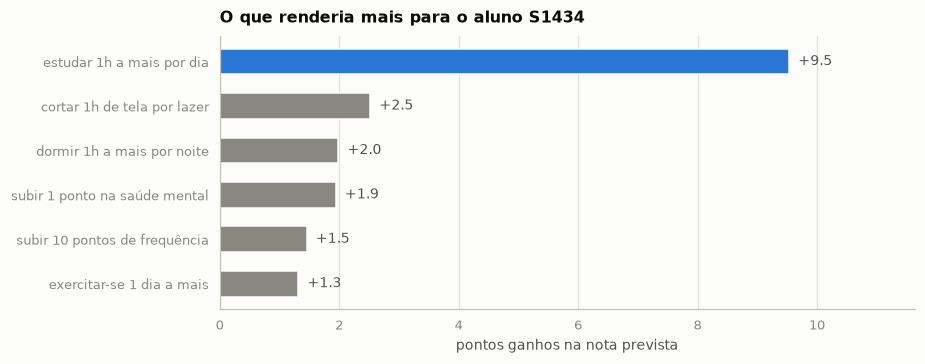

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))

ganhos = simular(habitos_exemplo).iloc[::-1]
# Emfase na maior alavanca; as demais ficam em cinza para não competir.
cores = [COR["serie_1"] if i == len(ganhos) - 1 else COR["suave"]
         for i in range(len(ganhos))]

ax.barh(np.arange(len(ganhos)), ganhos["ganho"], height=0.58, color=cores,
        edgecolor=COR["superficie"], linewidth=1)

for i, v in enumerate(ganhos["ganho"]):
    ax.text(v + 0.15, i, f"+{v:.1f}", va="center", fontsize=9, color=COR["tinta_2"])

ax.set_yticks(np.arange(len(ganhos)), ganhos["acao"])
ax.set_xlabel("pontos ganhos na nota prevista")
ax.set_title(f"O que renderia mais para o aluno {exemplo_id}")
ax.set_xlim(0, ganhos["ganho"].max() * 1.22)
so_grade(ax, eixo="x")
plt.tight_layout()
plt.show()

Para este aluno, estudar 1h a mais vale **+9,5 pontos**, quase quatro vezes a segunda alavanca. O ranking é o mesmo para quase todo mundo, porque os coeficientes são fixos e os limites da base raramente mordem.

E é aqui que a leitura precisa de honestidade, porque o número mais alto não é a melhor recomendação:

1. **Horas de estudo lidera sempre, e é a mais difícil de mudar por conversa.** "Estude mais uma hora por dia" é o conselho que todo aluno em dificuldade já ouviu, e continuar repetindo não é uma intervenção.
2. **Saúde mental e tempo de tela são as alavancas com alcance real.** O notebook 03 mostrou que, entre alunos que já estudam a mesma quantidade, são essas duas que mais separam o resultado. E são acionáveis: apoio psicológico e limite de tela são coisas que uma escola consegue oferecer.
3. **O simulador é aritmética, não promessa.** Ele responde "o que o modelo prevê se esse número mudar", não "o que vai acontecer se o aluno mudar de hábito". A base é sintética e tem hábitos independentes por construção, então nada aqui estabelece causa. Numa base real, mexer numa alavanca provavelmente mexeria em outras junto.

## 9. O app

Tudo acima vira interface em [`app.py`](../app.py), na raiz do repositório.

![Triagem de risco acadêmico](../assets/img/app.png)

**Duas formas de usar:**

1. **Aluno da base**: escolhe um `student_id`, vê os hábitos, a nota real, a prevista e o erro do modelo naquele caso.
2. **Cadastrar aluno novo**: informa os hábitos em sliders e recebe a previsão ao vivo. Os limites de cada campo vêm do domínio observado nos 1.000 alunos, porque fora dessa faixa o modelo estaria extrapolando.

Nos dois casos aparecem o veredito em três estados, a posição do aluno na distribuição da turma e o simulador de alavancas. O corte de aprovação é um slider na barra lateral, com 60 como padrão.

As outras duas abas entregam as tarefas 5 e 6: **Panorama da turma** tem o seletor de hábito e o mapa de calor, e **Insights** tem o impacto em pontos, o comparador de recortes e as recomendações.

### A paleta

O app usa **uma paleta só**, derivada da identidade visual do cliente: âmbar `#ffb73f` como cor de marca, grafite `#252a2d`, creme `#fff5e5` e a tipografia Red Hat.

Houve uma versão anterior com tema claro e escuro, e ela foi descartada. Manter duas paletas significa desenhar cada gráfico duas vezes, e o resultado no tema escuro ficou pior que o claro em todos eles, principalmente no mapa de calor. Uma paleta só, feita para o fundo em que vai aparecer, entrega mais do que duas meio resolvidas.

Três regras governam o uso da cor:

1. **O âmbar é reservado ao dado que importa.** No simulador só a maior alavanca recebe a cor de marca; as outras recuam para cinza. Usar âmbar em tudo o faria parar de apontar qualquer coisa.
2. **Âmbar e teal são os polos.** Servem para sinal positivo e negativo (no gráfico de impacto) e para as duas pontas da escala divergente (no mapa de calor), sem precisar de uma terceira cor.
3. **Grafite para marca fina.** Linha de tendência, ponto e barra de erro usam `#252a2d`, porque âmbar em traço de 2px sobre branco não tem contraste.

A tipografia é a mesma na interface e nos gráficos. O `config.toml` carrega Red Hat Text do Google Fonts para o Streamlit, e os mesmos arquivos ficam em `assets/fonts/` registrados no matplotlib: sem isso os gráficos sairiam em DejaVu Sans no meio de uma página em Red Hat.

Do menu ☰ ficou só a limpeza de cache. As opções de tema saíram junto com o tema escuro, e rerun, auto rerun, impressão e gravação de tela são ferramentas de quem desenvolve, não de quem usa.

### Rodar local

```
pip install -r requirements.txt
streamlit run app.py
```

### Publicar

O app foi feito para o **Streamlit Community Cloud**, que é gratuito e lê direto do repositório:

1. Subir o repositório para o GitHub como público.
2. Entrar em `share.streamlit.io` com a conta do GitHub.
3. Apontar para o repositório, arquivo `app.py`, Python 3.12.
4. Publicar. A URL sai no formato `https://<nome>.streamlit.app`.

Três detalhes do repositório existem para que esse deploy funcione sem ajuste: o `requirements.txt` é enxuto e não carrega o Jupyter (que vive em `requirements-notebooks.txt`), o caminho do CSV é resolvido a partir do próprio `app.py` em vez do diretório de execução, e o tema está em `.streamlit/config.toml` em vez de CSS injetado.

## 10. Síntese

### A aplicação

**Triagem de risco acadêmico com simulador de intervenção.** A coordenação pedagógica ordena a turma por risco antes da prova e, para cada aluno chamado, vê qual mudança de hábito renderia mais pontos.

### O que ela entrega

| | |
|---|---|
| Acerto do veredito | 92,1%, contra 72,0% de chutar que todos passam |
| Dos que reprovam, quantos pega | 85,0% |
| Erro típico da nota prevista | 4,1 pontos numa escala de 0 a 100 |
| Alunos na zona de incerteza | 203 de 1.000, sinalizados como tal |

### As quatro decisões de desenho que importam

1. **Veredito em três estados.** Perto do corte o modelo acerta 67,5%, pior que não ter modelo. Esses 20% da turma são marcados como zona de incerteza em vez de receberem um veredito falsamente confiante.
2. **Corte ajustável.** Deixar aluno reprovar sem aviso custa mais caro que chamar alguém que passaria, então a régua precisa ser da instituição, não do modelo.
3. **Sugestão limitada ao domínio da base.** O simulador não recomenda 9h de estudo quando o máximo observado é 8,3.
4. **Modelo escolhido por comparação, não por hábito.** Oito famílias em 53 configurações, e a regressão linear ganhou. Ela seria a escolha de qualquer jeito pela interpretabilidade que o simulador exige, mas agora isso é conclusão medida em vez de preferência.

### O que o modelo não resolve

Correlação não é causa, e este modelo mede associação. A base é sintética, com hábitos independentes entre si por construção, o que o notebook 03 demonstrou. **O app demonstra o método, e não deveria orientar decisão sobre aluno real** sem antes ser reajustado em dado verdadeiro, onde os hábitos vêm em pacote e mexer num mexe nos outros.

### Próximo passo

**Notebook 05, visualização**: mapa de calor de correlação, análise detalhada da variável de maior impacto e comparação por faixas.